In [1]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
import time
import threading
from queue import Queue, Empty

In [2]:
ol = Overlay("stft.bit")
ol.download()

print("Overlay loaded")
print("IP list:")
for name in ol.ip_dict.keys():
    print(" -", name)

Overlay loaded
IP list:
 - fft_0
 - stft_buffer_0
 - windowing_0
 - axi_dma_0
 - processing_system7_0


In [3]:
dma = ol.axi_dma_0

# 이름이 다르면 Cell 2 출력 보고 수정
stft_buffer = ol.stft_buffer_0
windowing = ol.windowing_0
fft_ip = ol.fft_0

print("DMA and STFT IPs loaded")

DMA and STFT IPs loaded


In [4]:
FS = 100_000          # decimated sampling rate
INPUT_SIZE = 6886     # 256 frames 만들기 위한 입력 샘플 수
NUM_FRAMES = 256
WIN_SIZE = 256
HOP = 26
FFT_SIZE = 1024
OUTPUT_SIZE = NUM_FRAMES * FFT_SIZE   # 262144

print("INPUT_SIZE =", INPUT_SIZE)
print("OUTPUT_SIZE =", OUTPUT_SIZE)
print("Output bytes =", OUTPUT_SIZE * 4)
print("Block time =", INPUT_SIZE / FS, "s")

INPUT_SIZE = 6886
OUTPUT_SIZE = 262144
Output bytes = 1048576
Block time = 0.06886 s


In [5]:
def start_hls_ip(ip, auto_restart=True):
    """
    HLS ap_ctrl_hs control register
    bit 0 = ap_start
    bit 7 = auto_restart
    """
    if auto_restart:
        ip.write(0x00, 0x81)   # ap_start=1, auto_restart=1
    else:
        ip.write(0x00, 0x01)   # ap_start=1 only


start_hls_ip(stft_buffer, auto_restart=True)
start_hls_ip(windowing, auto_restart=True)
start_hls_ip(fft_ip, auto_restart=True)

print("HLS IPs started")

HLS IPs started


In [6]:
input_buffer = allocate(shape=(INPUT_SIZE,), dtype=np.uint32)
output_buffer = allocate(shape=(OUTPUT_SIZE,), dtype=np.uint32)

print("input_buffer :", input_buffer.shape, input_buffer.dtype, input_buffer.nbytes, "bytes")
print("output_buffer:", output_buffer.shape, output_buffer.dtype, output_buffer.nbytes, "bytes")

input_buffer : (6886,) uint32 27544 bytes
output_buffer: (262144,) uint32 1048576 bytes


In [7]:
def pack_iq_to_u32(I_i16, Q_i16):
    """
    int16 I/Q를 uint32 complex word로 packing.

    HLS format:
    [31:16] = real / I
    [15:0]  = imag / Q
    """
    I_u16 = I_i16.astype(np.uint16).astype(np.uint32)
    Q_u16 = Q_i16.astype(np.uint16).astype(np.uint32)

    packed = (I_u16 << 16) | Q_u16
    return packed.astype(np.uint32)


def unpack_u32_to_iq(u32_arr):
    """
    uint32 complex word를 int16 real/imag로 unpack.
    """
    real_u16 = ((u32_arr >> 16) & 0xFFFF).astype(np.uint16)
    imag_u16 = (u32_arr & 0xFFFF).astype(np.uint16)

    real_i16 = real_u16.view(np.int16)
    imag_i16 = imag_u16.view(np.int16)

    return real_i16, imag_i16


def complex_to_q88_u32(x_complex, gain=1.0):
    """
    complex float input을 Q8.8 uint32 stream으로 변환.
    """
    xg = x_complex * gain

    xr = np.clip(np.real(xg), -128.0, 127.996)
    xi = np.clip(np.imag(xg), -128.0, 127.996)

    I_i16 = np.round(xr * 256).astype(np.int16)
    Q_i16 = np.round(xi * 256).astype(np.int16)

    return pack_iq_to_u32(I_i16, Q_i16)

In [8]:
def run_fpga_stft(x_block, gain=1.0):
    """
    Task2 역할:
    1. 6886 complex samples 입력
    2. Q8.8 변환
    3. DMA send/recv
    4. BUFFER → WINDOW → FFT 실행
    5. 256 x 1024 complex FFT 결과 반환
    """

    if len(x_block) < INPUT_SIZE:
        raise ValueError(f"x_block length must be >= {INPUT_SIZE}")

    x_block = x_block[:INPUT_SIZE]

    input_u32 = complex_to_q88_u32(x_block, gain=gain)

    input_buffer[:] = input_u32
    output_buffer[:] = 0

    input_buffer.flush()
    output_buffer.flush()

    t0 = time.time()

    # S2MM receive 먼저 걸고, 그 다음 MM2S send
    dma.recvchannel.transfer(output_buffer)
    dma.sendchannel.transfer(input_buffer)

    dma.sendchannel.wait()
    dma.recvchannel.wait()

    t1 = time.time()

    output_buffer.invalidate()

    out_u32 = np.array(output_buffer, dtype=np.uint32)

    Yr_i16, Yi_i16 = unpack_u32_to_iq(out_u32)

    Y = Yr_i16.astype(np.float32) + 1j * Yi_i16.astype(np.float32)

    Y_frames = Y.reshape(NUM_FRAMES, FFT_SIZE)

    return Y_frames, (t1 - t0)

In [9]:
n = np.arange(INPUT_SIZE)

# FFT bin 5에 정확히 걸리는 tone
f0 = 5 * FS / FFT_SIZE
x_test = 0.5 * np.exp(1j * 2 * np.pi * f0 * n / FS)

Y_frames, elapsed = run_fpga_stft(x_test, gain=1.0)

print("Y_frames shape:", Y_frames.shape)
print("elapsed:", elapsed, "s")
print("abs max:", np.abs(Y_frames).max())

mag_mean = np.mean(np.abs(Y_frames), axis=0)
peak_bin = np.argmax(mag_mean)

print("peak_bin:", peak_bin)
print("peak_freq:", peak_bin * FS / FFT_SIZE, "Hz")

Y_frames shape: (256, 1024)
elapsed: 0.10594415664672852 s
abs max: 128.69344
peak_bin: 5
peak_freq: 488.28125 Hz


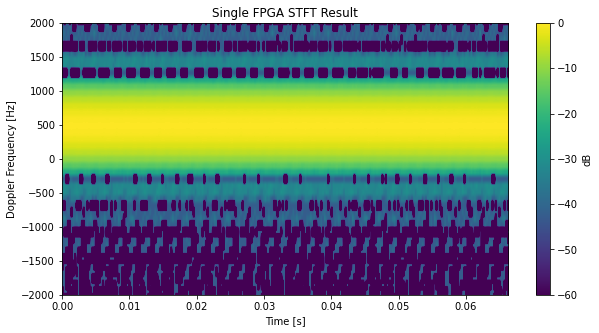

In [10]:
def make_sdb(Y_frames):
    Y_shift = np.fft.fftshift(Y_frames, axes=1)
    SdB = 20 * np.log10(np.abs(Y_shift) + 1e-9)
    SdB = SdB - np.max(SdB)
    return SdB


SdB = make_sdb(Y_frames)

F = (np.arange(FFT_SIZE) - FFT_SIZE // 2) * FS / FFT_SIZE
T = np.arange(NUM_FRAMES) * HOP / FS

plt.figure(figsize=(10, 5))
plt.imshow(
    SdB.T,
    aspect="auto",
    origin="lower",
    extent=[T[0], T[-1], F[0], F[-1]],
    vmin=-60,
    vmax=0
)
plt.ylim([-2000, 2000])
plt.colorbar(label="dB")
plt.xlabel("Time [s]")
plt.ylabel("Doppler Frequency [Hz]")
plt.title("Single FPGA STFT Result")
plt.show()

In [11]:
raw_queue = Queue(maxsize=4)
stft_queue = Queue(maxsize=2)

stop_event = threading.Event()

print("Queues created")

Queues created


In [12]:
def mock_task1():
    """
    Pluto RX 대신 임의 complex 신호를 6886 samples씩 만들어 raw_queue에 넣는다.
    실제 Pluto 연결 시 이 함수만 pluto_task1로 바꾸면 된다.
    """

    block_idx = 0

    while not stop_event.is_set():
        n = np.arange(INPUT_SIZE)

        # block마다 peak bin이 조금씩 움직이게 함
        bin_idx = 5 + (block_idx % 20)
        f0 = bin_idx * FS / FFT_SIZE

        x_block = 0.5 * np.exp(1j * 2 * np.pi * f0 * n / FS)

        # raw_queue가 꽉 차면 오래된 입력 하나 버림
        while raw_queue.full():
            try:
                raw_queue.get_nowait()
            except Empty:
                break

        raw_queue.put(x_block)

        block_idx += 1

        # 실제 6886 samples가 들어오는 시간과 비슷하게 sleep
        time.sleep(INPUT_SIZE / FS)

In [13]:
def task2_fpga_worker():
    """
    raw_queue에서 입력 block을 꺼내 FPGA STFT 처리 후
    stft_queue에 256 x 1024 결과를 넣는다.
    """

    count = 0

    while not stop_event.is_set():
        try:
            x_block = raw_queue.get(timeout=0.1)
        except Empty:
            continue

        try:
            Y_frames, elapsed = run_fpga_stft(x_block, gain=1.0)

            # stft_queue가 꽉 차면 오래된 결과 제거
            while stft_queue.full():
                try:
                    stft_queue.get_nowait()
                except Empty:
                    break

            # output_buffer가 재사용되므로 copy해서 넘김
            stft_queue.put(Y_frames.copy())

            count += 1

            if count % 10 == 0:
                print(f"Task2 processed {count} blocks, last DMA time = {elapsed:.4f} s")

        except Exception as e:
            print("Task2 error:", e)
            stop_event.set()
            break

In [14]:
def run_task3_plot(duration_sec=10):
    """
    stft_queue에서 최신 STFT 결과만 가져와 plot 갱신.
    새 figure를 계속 만들지 않고 imshow 데이터만 바꾼다.
    """

    F = (np.arange(FFT_SIZE) - FFT_SIZE // 2) * FS / FFT_SIZE
    T = np.arange(NUM_FRAMES) * HOP / FS

    plt.ion()

    fig, ax = plt.subplots(figsize=(10, 5))

    init_img = np.zeros((FFT_SIZE, NUM_FRAMES))

    im = ax.imshow(
        init_img,
        aspect="auto",
        origin="lower",
        extent=[T[0], T[-1], F[0], F[-1]],
        vmin=-60,
        vmax=0
    )

    ax.set_ylim([-2000, 2000])
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Doppler Frequency [Hz]")
    ax.set_title("Mock Task1 → FPGA STFT → Task3 Plot")
    fig.colorbar(im, ax=ax, label="dB")

    t_start = time.time()
    plot_count = 0

    while time.time() - t_start < duration_sec:
        try:
            Y_frames = stft_queue.get(timeout=0.5)
        except Empty:
            continue

        # Queue에 쌓인 것 중 최신 것만 사용
        while not stft_queue.empty():
            try:
                Y_frames = stft_queue.get_nowait()
            except Empty:
                break

        SdB = make_sdb(Y_frames)

        im.set_data(SdB.T)

        fig.canvas.draw_idle()
        fig.canvas.flush_events()

        plot_count += 1

        # plot 갱신률 제한
        time.sleep(0.1)

    plt.ioff()
    plt.show()

    print("Task3 plotted", plot_count, "frames")

Task2 processed 10 blocks, last DMA time = 0.1060 s
Task2 processed 20 blocks, last DMA time = 0.1061 s
Task2 processed 30 blocks, last DMA time = 0.1061 s
Task2 processed 40 blocks, last DMA time = 0.1068 s


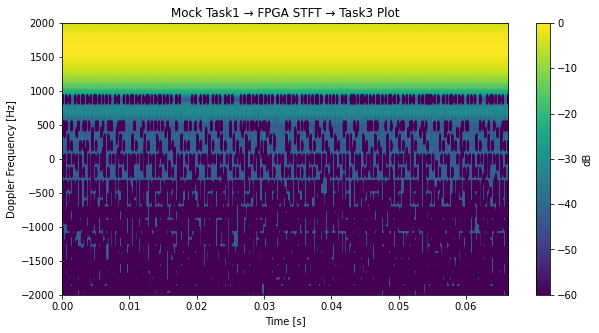

Task3 plotted 7 frames
Pipeline stopped


In [15]:
# 이전 실행 상태 정리
stop_event.clear()

t1 = threading.Thread(target=mock_task1, daemon=True)
t2 = threading.Thread(target=task2_fpga_worker, daemon=True)

t1.start()
t2.start()

run_task3_plot(duration_sec=10)

stop_event.set()

print("Pipeline stopped")

In [16]:
stop_event.set()

try:
    input_buffer.freebuffer()
    output_buffer.freebuffer()
except Exception as e:
    print("buffer free warning:", e)

print("Cleaned up")

Cleaned up
